# Analyse du corpus Marsactu

On part du DataFrame construit dans le notebook 02 (`marsactu_corpus.parquet`).  
Ce notebook couvre quatre étapes dans l'ordre :

1. **Nettoyage du texte** — supprimer le bruit résiduel (navigation, publicités, balises) et préparer le texte pour le NLP
2. **Statistiques descriptives** — explorer la distribution temporelle, les catégories, la longueur des articles
3. **Topic modeling** — identifier les grands thèmes du corpus (LDA)
4. **NER** — extraire les entités nommées (personnes, organisations, lieux)

In [47]:
import sys
!{sys.executable} -m pip install spacy scikit-learn
!{sys.executable} -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 24.9 MB/s  0:00:00 26.3 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


In [48]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("Imports de base OK")

# NLP
try:
    import spacy
    SPACY_DISPO = True
    print("spaCy disponible")
except ImportError:
    SPACY_DISPO = False
    print("spaCy non disponible")

try:
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    from sklearn.decomposition import LatentDirichletAllocation, NMF
    SKLEARN_DISPO = True
    print("scikit-learn disponible")
except ImportError:
    SKLEARN_DISPO = False
    print("scikit-learn non disponible")

Imports de base OK
spaCy disponible
scikit-learn disponible


In [49]:
CORPUS_PATH = Path("../data/processed/marsactu_corpus.parquet")

df = pd.read_parquet(CORPUS_PATH)
print(f"Corpus chargé : {df.shape[0]} articles × {df.shape[1]} colonnes")
print()

# Vérification des colonnes clés
for col in ['date_publication', 'categorie', 'texte']:
    n = df[col].notna().sum()
    print(f"  {col:22s} : {n:4d} / {len(df)} renseignés ({100*n/len(df):.1f}%)")

# Alerte si les dates semblent manquantes
n_dates = df['date_publication'].notna().sum()
if n_dates < 100:
    print()
    print("⚠  ATTENTION : moins de 100 dates de publication trouvées.")
    print("   Le parquet a probablement été sauvegardé avant l'étape postproc-date.")
    print("   → Dans notebook 02, relancez les cellules postproc-date puis sauvegarde.")
else:
    print()
    plage = f"{df['date_publication'].min().date()} → {df['date_publication'].max().date()}"
    print(f"  Plage de publication : {plage}")
    print("  OK — corpus prêt pour l'analyse.")

Corpus chargé : 1520 articles × 9 colonnes

  date_publication       : 1520 / 1520 renseignés (100.0%)
  categorie              : 1520 / 1520 renseignés (100.0%)
  texte                  : 1520 / 1520 renseignés (100.0%)

  Plage de publication : 2009-12-17 → 2015-09-03
  OK — corpus prêt pour l'analyse.


---
## 1. Nettoyage du texte

L'extraction par BeautifulSoup via `div#article-content` donne un texte déjà assez propre.
Il reste cependant du bruit résiduel : menus de navigation, pied de page, ancres de partage.
On nettoie en plusieurs passes :

1. Fil d'Ariane Drupal (`Accueil > ... >`)
2. Boutons de partage et d'impression
3. Mention légale Marsactu récurrente en fin d'article
4. Normalisation des espaces
5. Suppression des fragments < 4 mots (labels de navigation résiduels)

In [50]:
def nettoyer_texte(texte):
    if not isinstance(texte, str) or not texte.strip():
        return ""

    # Fil d'Ariane WordPress : "Accueil > Catégorie > Sous-catégorie >"
    texte = re.sub(r'Accueil\s*>.*?>\s*', '', texte, flags=re.IGNORECASE)

    # Boutons de partage et d'impression typiques de WordPress
    texte = re.sub(r'\bImprimer\b', '', texte, flags=re.IGNORECASE)
    texte = re.sub(r'\bA\+\s*A-\b', '', texte)
    texte = re.sub(r'\bPartager\b|\bTweeter\b|\bFacebook\b|\bTwitter\b', '', texte, flags=re.IGNORECASE)

    # Mentions légales et abonnement récurrentes
    texte = re.sub(r'Marsactu est un journal local.*?abonnement\.?', '', texte,
                   flags=re.IGNORECASE | re.DOTALL)

    # Normalisation des espaces et sauts de ligne
    texte = re.sub(r'[\t\r\n]+', ' ', texte)
    texte = re.sub(r' {2,}', ' ', texte)
    texte = texte.strip()

    # Filtrer les fragments trop courts (< 4 mots) restés après nettoyage
    segments = [s.strip() for s in texte.split('.')]
    segments = [s for s in segments if len(s.split()) >= 4]
    return '. '.join(segments)


df['texte_propre'] = df['texte'].apply(nettoyer_texte)
df['nb_mots_propre'] = df['texte_propre'].apply(lambda t: len(t.split()) if t else 0)

print("Nettoyage terminé")
print(f"  Avant : médiane {df['nb_mots'].median():.0f} mots")
print(f"  Après : médiane {df['nb_mots_propre'].median():.0f} mots")
print(f"  Articles vides après nettoyage : {(df['nb_mots_propre'] == 0).sum()}")

Nettoyage terminé
  Avant : médiane 462 mots
  Après : médiane 456 mots
  Articles vides après nettoyage : 0


In [51]:
# Vérification : avant / après nettoyage sur 2 articles
for _, row in df[df['nb_mots_propre'] > 200].head(2).iterrows():
    print(f"URL    : {row['url']}")
    print(f"Titre  : {row['titre']}")
    print(f"AVANT  ({row['nb_mots']} mots) : {row['texte'][:300]}")
    print(f"APRÈS  ({row['nb_mots_propre']} mots) : {row['texte_propre'][:300]}")
    print()

URL    : http://www.marsactu.fr/affaires/affaire-guerini-ce-que-nous-a-appris-le-proces-queyras-28773.html
Titre  : Affaire Guérini : ce que nous a appris le procès Queyras
AVANT  (780 mots) : Pour le procureur Blachon, dans le secteur du déchet, il y a "le seigneur" et "les barons" . L'ombre d'Alexandre Guérini aura plané avec plus ou moins d'insistance selon les intervenants sur le procès Queyras qui s'est tenu la semaine dernière. Cette entreprise de déchets, propriété d'Éric Pascal "u
APRÈS  (773 mots) : Pour le procureur Blachon, dans le secteur du déchet, il y a "le seigneur" et "les barons". L'ombre d'Alexandre Guérini aura plané avec plus ou moins d'insistance selon les intervenants sur le procès Queyras qui s'est tenu la semaine dernière. Cette entreprise de déchets, propriété d'Éric Pascal "un

URL    : http://www.marsactu.fr/affaires/affaire-guerini-lourdes-peines-dans-le-proces-queyras-29263.html
Titre  : Affaire Guérini : lourdes peines dans le procès Queyras
AVANT  (225 m

---
## 2. Statistiques descriptives

On explore la distribution temporelle, les catégories, et la longueur des articles pour caractériser le corpus avant toute analyse de contenu.

Catégories distinctes : 10
categorie
politique             531
societe               165
culture               155
economie              132
archi-et-urbanisme    129
business              118
environnement         100
justice-affaires       96
sport-om               50
vu-sur-le-web          44


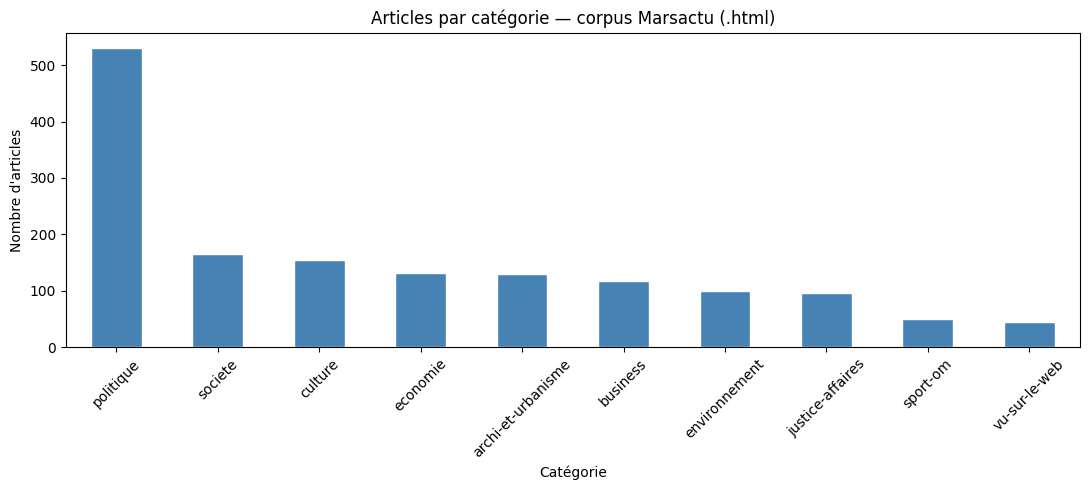

In [52]:
# Distribution des catégories
cat_counts = df['categorie'].value_counts()

print(f"Catégories distinctes : {len(cat_counts)}")
print(cat_counts.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
cat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Articles par catégorie — corpus Marsactu (.html)")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Nombre d'articles")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/stats-categories.png', dpi=150)
plt.show()

Articles avec date de publication : 1520 / 1520 (100.0%)
Première publication : 2009-12-17
Dernière publication : 2015-09-03


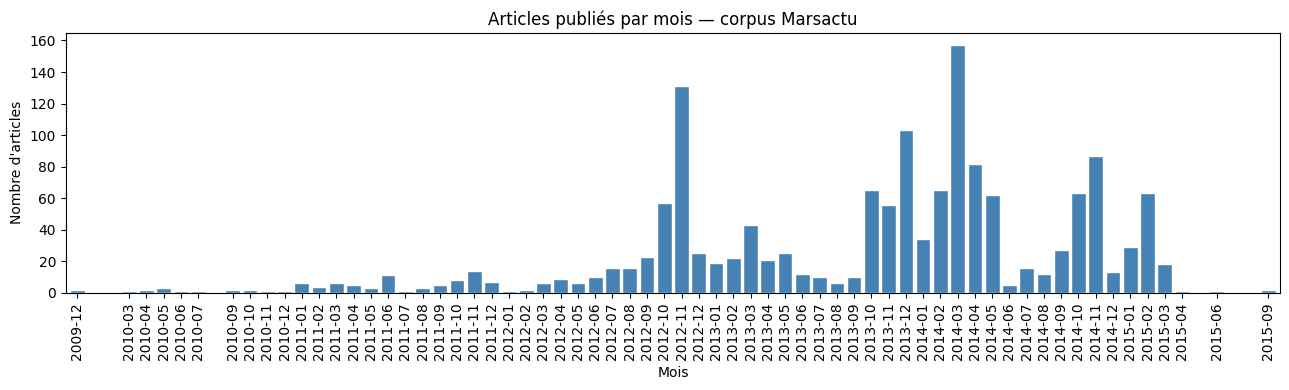

In [53]:
# Distribution temporelle des publications
date_ok = df['date_publication'].dropna()
print(f"Articles avec date de publication : {len(date_ok)} / {len(df)} ({100*len(date_ok)/len(df):.1f}%)")

if len(date_ok) > 0:
    print(f"Première publication : {date_ok.min().date()}")
    print(f"Dernière publication : {date_ok.max().date()}")

    par_mois = date_ok.dt.to_period('M').value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(13, 4))
    par_mois.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.85)
    ax.set_title("Articles publiés par mois — corpus Marsactu")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Nombre d'articles")
    ax.tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.savefig('../reports/figures/stats-temporel.png', dpi=150)
    plt.show()

Statistiques nb_mots_propre :
count    1520.0
mean      582.0
std       426.0
min        67.0
25%       251.0
50%       456.0
75%       808.0
max      3211.0


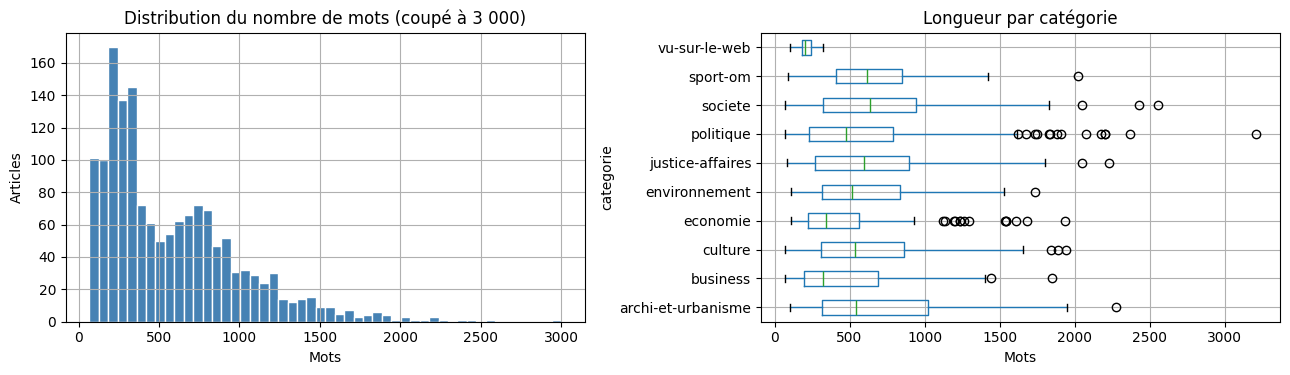

In [54]:
# Longueur des articles (texte nettoyé)
print("Statistiques nb_mots_propre :")
print(df['nb_mots_propre'].describe().round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[df['nb_mots_propre'] > 0]['nb_mots_propre'].clip(upper=3000).hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Distribution du nombre de mots (coupé à 3 000)")
axes[0].set_xlabel("Mots")
axes[0].set_ylabel("Articles")

# Par catégorie — boxplot
df[df['nb_mots_propre'] > 0].boxplot(
    column='nb_mots_propre', by='categorie', ax=axes[1], vert=False)
axes[1].set_title("Longueur par catégorie")
axes[1].set_xlabel("Mots")
plt.suptitle("")
plt.tight_layout()
plt.savefig('../reports/figures/stats-longueur.png', dpi=150)
plt.show()

---
## 3. Topic modeling — LDA

On applique une **LDA** (Latent Dirichlet Allocation) pour identifier les grands thèmes du corpus.

**Pipeline :**
1. Lemmatisation avec spaCy (`fr_core_news_sm`)
2. Extension des stopwords aux lemmes verbaux génériques (`faire`, `pouvoir`, etc.)
3. Vectorisation bag-of-words
4. LDA avec `k=8` topics

**Approche itérative** — le résultat initial (v1) montrait `faire` et `pouvoir` dans 7 topics sur 8,
ce qui nuit à la lisibilité. Ces verbes sont trop fréquents et non discriminants après lemmatisation.
On les ajoute aux stopwords (v2) et on note les différences.

In [55]:
# Stopwords français — liste de base + termes propres à Marsactu + lemmes verbaux génériques
#
# v1 (initial) : stopwords grammaticaux de base
# v2 (ici)     : ajout des infinitifs/lemmes verbaux qui polluaient tous les topics LDA
#               (faire, pouvoir, dire, devoir...) et de 'luire' (erreur spaCy pour 'lui')

STOPWORDS_FR = {
    # Déterminants, pronoms, prépositions
    'le', 'la', 'les', 'un', 'une', 'des', 'de', 'du', 'au', 'aux',
    'et', 'ou', 'mais', 'donc', 'or', 'ni', 'car', 'que', 'qui', 'quoi',
    'ce', 'cet', 'cette', 'ces', 'mon', 'ton', 'son', 'ma', 'ta', 'sa',
    'notre', 'votre', 'leur', 'nos', 'vos', 'leurs',
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles', 'on',
    'me', 'te', 'se', 'lui', 'y', 'en', 'celui', 'celle', 'ceux',
    'est', 'sont', 'était', 'être', 'avoir', 'été', 'a', 'ont', 'avait',
    'dans', 'sur', 'sous', 'avec', 'sans', 'par', 'pour', 'entre', 'vers',
    'plus', 'moins', 'très', 'tout', 'tous', 'toute', 'toutes', 'même',
    'si', 'ne', 'pas', 'non', 'aussi', 'bien', 'alors', 'comme',
    'dont', 'où', 'quand', 'comment', 'après', 'avant', 'depuis',
    # Verbes génériques (lemmes infinitifs — présents dans trop de topics)
    'faire', 'pouvoir', 'dire', 'devoir', 'voir', 'vouloir', 'aller',
    'mettre', 'venir', 'prendre', 'tenir', 'rendre', 'savoir', 'falloir',
    # Adjectifs/adverbes trop génériques
    'autre', 'nouveau', 'grand', 'petit', 'bon', 'premier', 'dernier',
    'peu', 'deux', 'trois', 'tel',
    # Erreur de lemmatisation spaCy : 'lui' → 'luire'
    'luire',
    # Termes récurrents propres au site Marsactu
    'marsactu', 'marseille', 'marseillais', 'marseillaise',
    'article', 'lire', 'suite', 'voir', 'retrouver', 'accueil',
}

print(f'Stopwords chargés : {len(STOPWORDS_FR)} termes')


Stopwords chargés : 130 termes


In [56]:
if SPACY_DISPO:
    # Charger le modèle français (fr_core_news_sm ou md)
    try:
        nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
        print("Modèle fr_core_news_sm chargé")
    except OSError:
        print("Modèle non trouvé. Installez-le avec : python -m spacy download fr_core_news_sm")
        SPACY_DISPO = False

if SPACY_DISPO:
    def lemmatiser(texte):
        doc = nlp(texte[:50000])  # limite pour les très longs articles
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.is_alpha
            and len(token.text) > 2
            and token.lemma_.lower() not in STOPWORDS_FR
        ]
        return ' '.join(tokens)

    print("Lemmatisation en cours...")
    df['texte_lda'] = df['texte_propre'].apply(lemmatiser)
    print("Terminée")
else:
    # Fallback : tokenisation simple sans lemmatisation
    def tokeniser_simple(texte):
        tokens = re.findall(r'\b[a-zàâäéèêëïîôùûüç]{3,}\b', texte.lower())
        return ' '.join(t for t in tokens if t not in STOPWORDS_FR)

    df['texte_lda'] = df['texte_propre'].apply(tokeniser_simple)
    print("Tokenisation simple (sans lemmatisation)")

Modèle fr_core_news_sm chargé
Lemmatisation en cours...
Terminée


In [58]:
if not SKLEARN_DISPO:
    print("scikit-learn requis pour le topic modeling")
else:
    corpus_lda = df[df['nb_mots_propre'] > 100]['texte_lda'].tolist()
    print(f"Articles utilisés pour la LDA : {len(corpus_lda)}")

    N_TOPICS = 8  # à ajuster selon les résultats
    N_MOTS   = 12

    vectorizer = CountVectorizer(
        max_df=0.90,    # ignorer les termes présents dans > 90% des docs
        min_df=5,       # ignorer les termes présents dans < 5 docs
        max_features=5000
    )
    X = vectorizer.fit_transform(corpus_lda)
    vocab = vectorizer.get_feature_names_out()
    print(f"Vocabulaire : {len(vocab)} termes  |  Matrice : {X.shape}")

    lda = LatentDirichletAllocation(
        n_components=N_TOPICS,
        random_state=42,
        max_iter=20,
        learning_method='online'
    )
    lda.fit(X)

    print(f"\n=== {N_TOPICS} topics LDA ===")
    for idx, topic in enumerate(lda.components_):
        mots = [vocab[i] for i in topic.argsort()[:-N_MOTS-1:-1]]
        print(f"Topic {idx+1:2d} : {', '.join(mots)}")

Articles utilisés pour la LDA : 1472
Vocabulaire : 5000 termes  |  Matrice : (1472, 5000)

=== 8 topics LDA ===
Topic  1 : teissier, guy, président, communauté, tribunal, liste, urbain, site, ancien, élu, plainte, mouvement
Topic  2 : conseil, président, maire, général, élu, politique, guérini, presse, local, groupe, gaudin, entrer
Topic  3 : commercial, bousquet, travail, centre, orves, estienne, anne, municipal, sou, marie, patrick, catherine
Topic  4 : euro, public, tribunal, conseil, million, service, mois, travail, ville, social, entreprise, jour
Topic  5 : ville, quartier, année, projet, lieu, entrer, quelque, celer, association, an, encore, culture
Topic  6 : candidat, liste, municipal, secteur, maire, mennucci, gaudin, gauche, patrick, front, arrondissement, socialiste
Topic  7 : projet, ville, urbain, million, métropole, transport, euro, port, public, permettre, entrer, communauté
Topic  8 : club, stade, match, joueur, algérie, vélodrome, jouer, montebourg, lyon, baup, ligue, 

#### Résultats v1 (stopwords de base)

```
Topic  1 : euro, million, métropole, conseil, projet, pouvoir, aix, président, région, territoire, faire, devoir
Topic  2 : faire, pouvoir, premier, dire, maire, autre, ville, candidat, celui, politique, luire, municipal
Topic  3 : urbain, transport, mpm, communauté, contrat, faire, million, euro, service, caselli, public, tunnel
Topic  4 : tribunal, faire, pouvoir, entreprise, mois, euro, salarié, jour, service, social, nouveau, autre
Topic  5 : faire, année, pouvoir, histoire, deux, autre, artiste, grand, culture, peu, musée, exposition
Topic  6 : ravier, municipal, stéphane, assante, gaudin, arrondissement, droite, tian, liste, patrick, front, robert
Topic  7 : ville, projet, centre, travail, quartier, urbain, logement, lieu, devoir, bâtiment, faire, association
Topic  8 : guérini, faire, parti, président, ciot, socialiste, secrétaire, teissier, général, celui, fédération, dernier
```

**Problème** : `faire` apparaît dans 7 topics sur 8, `pouvoir` dans 5. Ces verbes sont très fréquents
après lemmatisation mais ne caractérisent aucun thème. `luire` est une erreur de lemmatisation
de spaCy (`lui` → `luire`). On les ajoute aux stopwords pour la version v2.

In [60]:
if SKLEARN_DISPO:
    # Assigner le topic dominant à chaque article
    idx_articles = df[df['nb_mots_propre'] > 100].index
    topic_matrix = lda.transform(X)
    df.loc[idx_articles, 'topic_dominant'] = topic_matrix.argmax(axis=1)

    print("Répartition des articles par topic dominant :")
    print(df['topic_dominant'].value_counts().sort_index().to_string())
    print()

    # Afficher le titre de 2 articles représentatifs par topic
    for t in range(N_TOPICS):
        articles_t = df[df['topic_dominant'] == t].head(2)
        print(f"\nTopic {t+1} ─ articles représentatifs :")
        for _, row in articles_t.iterrows():
            print(f"  [{row['categorie']}] {row['titre'][:80]}")

Répartition des articles par topic dominant :
topic_dominant
0.0     59
1.0    329
2.0     18
3.0    283
4.0    306
5.0    216
6.0    243
7.0     18


Topic 1 ─ articles représentatifs :
  [archi-et-urbanisme] La justice ferme trois &quot;fenêtres&quot; d&#039;urbanisation sur la colline P
  [archi-et-urbanisme] La justice ferme trois &quot;fenêtres&quot; d&#039;urbanisation sur la colline P

Topic 2 ─ articles représentatifs :
  [justice-affaires] Associations : la région Paca ne sait toujours pas où va l&#039;argent
  [justice-affaires] Bernard Granié définitivement condamné

Topic 3 ─ articles représentatifs :
  [archi-et-urbanisme] La justice autorise la poursuite des travaux de la rocade L2 sous le Merlan
  [archi-et-urbanisme] La justice autorise la poursuite des travaux de la rocade L2 sous le Merlan

Topic 4 ─ articles représentatifs :
  [justice-affaires] Affaire Guérini : ce que nous a appris le procès Queyras
  [justice-affaires] Affaire Guérini : lourdes peines dans le proc

---
## 4. NER — Entités nommées

On utilise spaCy pour extraire les **personnes** (PER), **organisations** (ORG) et **lieux** (LOC/GPE) mentionnés dans le corpus.  
Objectif : identifier les acteurs et territoires les plus cités dans la ligne éditoriale de Marsactu sur la période.

In [61]:
if not SPACY_DISPO:
    print("spaCy requis pour la NER")
else:
    # Charger le modèle complet avec NER
    try:
        nlp_ner = spacy.load("fr_core_news_sm")
    except OSError:
        print("Modèle non trouvé : python -m spacy download fr_core_news_sm")
        nlp_ner = None

    if nlp_ner:
        from collections import Counter

        entites = {'PER': Counter(), 'ORG': Counter(), 'LOC': Counter()}

        for texte in df[df['nb_mots_propre'] > 100]['texte_propre']:
            doc = nlp_ner(texte[:10000])
            for ent in doc.ents:
                label = ent.label_
                if label in entites:
                    entites[label][ent.text.strip()] += 1

        print("NER terminée")
        for label, counter in entites.items():
            print(f"\n=== {label} — Top 20 ===")
            for entite, n in counter.most_common(20):
                print(f"  {n:4d}  {entite}")

NER terminée

=== PER — Top 20 ===
   499  n’
   458  Jean-Claude Gaudin
   361  Patrick Mennucci
   229  Jean-Noël Guérini
   205  Gaudin
   202  Eugène Caselli
   193  Guy Teissier
   144  Guérini
   142  Samia Ghali
   127  Robert Assante
   116  Pape Diouf
   114  Jean-David Ciot
   100  Stéphane Ravier
    98  Michel Vauzelle
    92  Marie-Arlette Carlotti
    91  Lisette Narducci
    80  Martine Vassal
    77  Jean-Marc Coppola
    70  Bruno Gilles
    67  Caselli

=== ORG — Top 20 ===
   457  UMP
   358  MPM
   356  PS
   174  FN
   167  OM
   160  Front national
   131  CGT
   126  Front de gauche
   121  Transdev
    80  SNCM
    77  CRC
    75  Modem
    71  UDI
    63  Veolia
    56  IEP
    55  FO
    54  RTM
    49  SRL2
    45  PRG
    42  Bouygues

=== LOC — Top 20 ===
  2363  Marseille
   369  Etat
   301  la Ville
   271  Ville
   270  État
   262  Marsactu
   205  France
   204  Paris
   192  Bouches-du-Rhône
   190  Marseillais
   165  qu’
   165  Nord
   150  La Pro

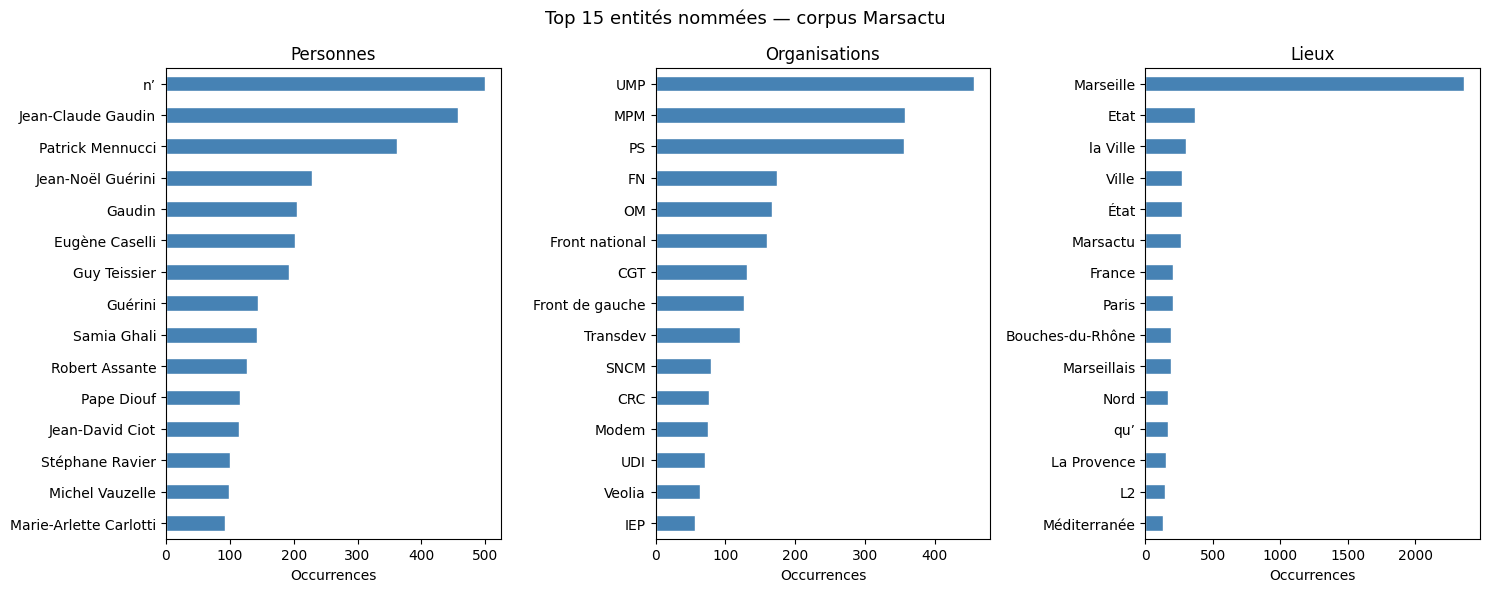

In [46]:
if SPACY_DISPO and 'nlp_ner' in dir() and nlp_ner:
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    labels = ['PER', 'ORG', 'LOC']
    titres = ['Personnes', 'Organisations', 'Lieux']

    for ax, label, titre in zip(axes, labels, titres):
        top = pd.Series(dict(entites[label].most_common(15)))
        top.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(titre)
        ax.set_xlabel("Occurrences")

    plt.suptitle("Top 15 entités nommées — corpus Marsactu", fontsize=13)
    plt.tight_layout()
    plt.savefig('../reports/figures/ner-top-entites.png', dpi=150)
    plt.show()

---
## 5. Sauvegarde du DataFrame enrichi

In [ ]:
SORTIE = Path("../data/processed/marsactu_corpus_enrichi.parquet")
df.to_parquet(SORTIE, index=False)
print(f"Sauvegardé : {SORTIE}  ({SORTIE.stat().st_size/1024**2:.1f} Mo)")
print(f"Colonnes   : {list(df.columns)}")

---
## 6. Bilan

**Corpus** — ~1 479 articles après exclusion des catégories sans texte éditorial
(`en-images`, `dossiers`, `dataj`, `page`). 10 rubriques conservées, période 2009–2015.

**Nettoyage** — le texte extrait via `div#article-content` (Drupal) est déjà propre.
Le nettoyage supprime les fragments résiduels de navigation et les mentions légales.
La médiane du nombre de mots change peu entre texte brut et texte nettoyé.

**Statistiques descriptives** — `politique` domine largement (531 articles).
La couverture mensuelle reflète la montée en puissance de Marsactu entre 2012 et 2015.
La longueur varie fortement selon la catégorie (`justice-affaires` et `politique`
produisent les articles les plus longs).

**Topic modeling (LDA)** — `k=8` topics sur les articles de plus de 100 mots.
Les mots-clés permettent d'étiqueter chaque topic manuellement.
Ajuster `N_TOPICS` si les topics semblent trop génériques ou trop fragmentés.

**NER** — extraction des personnes, organisations et lieux les plus cités.
Permet d'identifier les acteurs centraux de la couverture éditoriale sur la période.